# Три метода фильтрации канала Парето: точный, ЦПТ с одним каналом, ЦПТ с двумя каналами

Ноутбук сравнивает три подхода к фильтрации по одним и тем же сохранённым наблюдениям канала Парето:

1. **Точный фильтр Парето** -- готовая оценка (`theta_est`, `y_est`) загружается из pickle-архива `saved_path_pareto_obs_exact` и не пересчитывается, а лишь прореживается на общую сетку блоков.
2. **ЦПТ, 1 канал** (`pareto_obs_approx`) -- гауссовская аппроксимация по сумме блока $S_1=\sum_{k=1}^{2n}\xi_k$.
3. **ЦПТ, 2 канала** (`pareto_obs_approx_2ch`) -- гауссовская аппроксимация по паре $(S_1, S_2)$, где $S_2=\sum_{k=1}^{2n}(-1)^k\xi_k$.

При постоянном на блоке состоянии $(\theta, Y)$

$$\mathbb{E}\,S_1=2n\,(Y_1+Y_2),\qquad \operatorname{Var}S_1=2n\,\frac{Y_2^2}{12},$$
$$\mathbb{E}\,S_2=0,\qquad \operatorname{Var}S_2=2n\,\frac{Y_2^2}{12},$$
$$\operatorname{Cov}(S_1,S_2)=\frac{Y_2^2}{12}\sum_{k=1}^{2n}(-1)^k=0.$$

Знакопеременный канал $S_2$ несёт ту же дисперсию, что и $S_1$, но нулевое среднее и не коррелирован с ним, поэтому совместная плотность аппроксимируется произведением двух независимых нормальных плотностей $N(m,v)\times N(0,v)$ -- ровно так, как это делает конфиг `pareto_obs_approx_2ch` с двумя каналами `NORMAL`. Оба ЦПТ-фильтра пересчитываются заново по одним и тем же непересекающимся блокам одних и тех же исходных наблюдений $\xi_k$, поэтому сравнение всех трёх методов честное.

In [1]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np

from discretized_filter.config import set_config
from discretized_filter.core.filter import Filter

# Число исходных наблюдений с шагом ht=1 в одном ЦПТ-блоке.
HT_CLT = 20

# Относительный путь ниже разрешается от корня репозитория.
EXACT_RESULTS_DIR = Path('saved_path_pareto_obs_exact')

## Загрузка сохранённых результатов

Загружаются ровно шесть pickle-файлов точного эксперимента. Консолидированные архивы и результаты ранее посчитанных аппроксимаций не используются. Резолвер понимает как прямой каталог репозитория, так и указанный серверный layout, в котором абсолютный путь повторён внутри каталога.

In [ ]:
ARTIFACT_NAMES = (
    'theta', 'y', 't', 'theta_est', 'y_est', 'observations',
)

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / 'configs').is_dir() else cwd.parent
configured_dir = EXACT_RESULTS_DIR.expanduser()
if not configured_dir.is_absolute():
    configured_dir = ROOT / configured_dir

# Для /a/b/saved_path/... дублированный вариант имеет вид
# /a/b/saved_path/a/b/saved_path.
duplicated_dir = configured_dir / Path(*configured_dir.parts[1:])
candidates = [
    configured_dir,
    duplicated_dir,
    ROOT / 'saved_path_pareto_obs_exact',
]

def has_all_artifacts(directory):
    return all((directory / f'{name}.pkl').is_file() for name in ARTIFACT_NAMES)

DATA_DIR = next((path for path in candidates if has_all_artifacts(path)), None)
if DATA_DIR is None:
    checked = '\n'.join(f'  - {path}' for path in candidates)
    raise FileNotFoundError(
        'Не найден полный набор pickle-артефактов. Проверены:\n' + checked
    )

def load_pickle(name):
    with (DATA_DIR / f'{name}.pkl').open('rb') as handle:
        return pickle.load(handle)

loaded = {name: load_pickle(name) for name in ARTIFACT_NAMES}
theta = np.asarray(loaded['theta'])
y = np.asarray(loaded['y'])
jump_times = np.asarray(loaded['t'])
theta_est_exact = np.asarray(loaded['theta_est'])
y_est_exact = np.asarray(loaded['y_est'])
observations = np.asarray(loaded['observations'])
if observations.ndim == 1:
    observations = observations[:, None]

print(f'Каталог данных: {DATA_DIR}')
print(f'Загружено исходных наблюдений: {len(observations):,}')
print(f'Загружена готовая точная оценка: {theta_est_exact.shape}')

## Подготовка непересекающихся блоков и трёх входов

`pareto_obs_approx.py` задаёт для одного исходного наблюдения условные моменты

$$C_\mu=Y_1+Y_2, \qquad C_{\sigma^2}=Y_2^2/12$$

для единственного канала -- суммы блока $S_1$. `pareto_obs_approx_2ch.py` задаёт те же моменты для прямого канала $S_1$ и $C_\mu=0$, $C_{\sigma^2}=Y_2^2/12$ для знакопеременного канала $S_2$. Из одних и тех же непересекающихся блоков исходных наблюдений строятся два входа для фильтров: `observations_one` -- одноканальный (только $S_1$), и `observations_two` -- двухканальный (пара $(S_1, S_2)$). Последний неполный блок не дополняется и не переиспользуется: его остаток явно отбрасывается.

In [3]:
cfg_exact = set_config('pareto_obs')
cfg_one = set_config('pareto_obs_approx')
cfg_two = set_config('pareto_obs_approx_2ch')

assert isinstance(HT_CLT, (int, np.integer)) and not isinstance(HT_CLT, bool), (
    'HT_CLT должен быть положительным целым числом'
)
assert HT_CLT > 0, 'HT_CLT должен быть положительным'
assert np.isclose(cfg_exact.ht, 1.0), (
    f'Ожидался единичный шаг точного эксперимента, получен ht={cfg_exact.ht}'
)
ratio_float = HT_CLT / cfg_exact.ht
assert np.isclose(ratio_float, round(ratio_float)), (
    f'HT_CLT={HT_CLT} должен быть кратен шагу точного фильтра ht={cfg_exact.ht}'
)
BLOCK_SIZE = int(round(ratio_float))
assert BLOCK_SIZE % 2 == 0, (
    'Знакопеременная сумма блока имеет нулевое среднее лишь при чётном '
    'размере блока: BLOCK_SIZE должен быть чётным'
)

assert cfg_exact.K == 1, 'Точный фильтр должен иметь один канал наблюдений'
assert cfg_one.K == 1, 'Одноканальная ЦПТ-аппроксимация должна иметь K=1'
assert cfg_two.K == 2, 'Двухканальная ЦПТ-аппроксимация должна иметь K=2'
assert cfg_exact.N == cfg_one.N == cfg_two.N
assert cfg_exact.M == cfg_one.M == cfg_two.M
assert np.array_equal(cfg_exact.Lambda, cfg_one.Lambda)
assert np.array_equal(cfg_exact.Lambda, cfg_two.Lambda)
assert np.array_equal(cfg_exact.M_net, cfg_one.M_net)
assert np.array_equal(cfg_exact.M_net, cfg_two.M_net)
assert np.array_equal(cfg_exact.delta, cfg_one.delta)
assert np.array_equal(cfg_exact.delta, cfg_two.delta)
assert theta.ndim == 1 and jump_times.ndim == 1
assert y.ndim == 2 and len(theta) == len(y) == len(jump_times)
assert observations.ndim == 2 and observations.shape[1] == cfg_exact.K
assert theta_est_exact.shape == (len(observations) + 1, cfg_exact.N)
assert y_est_exact.shape == (len(observations) + 1, cfg_exact.M)
assert np.all(np.diff(jump_times) >= 0), 'Времена скачков должны возрастать'

n_blocks, remainder = divmod(len(observations), BLOCK_SIZE)
assert n_blocks > 0, 'Для выбранного HT_CLT нет ни одного полного блока'
n_used = n_blocks * BLOCK_SIZE

blocks = observations[:n_used].reshape(n_blocks, BLOCK_SIZE, cfg_exact.K)
signs = (-1.0) ** np.arange(1, BLOCK_SIZE + 1)   # (-1)^k, k = 1..BLOCK_SIZE
obs_sum = blocks.sum(axis=1)[:, 0]
obs_alt = (blocks[:, :, 0] * signs).sum(axis=1)

observations_one = obs_sum[:, None]
observations_two = np.column_stack([obs_sum, obs_alt])
assert observations_one.shape == (n_blocks, cfg_one.K)
assert observations_two.shape == (n_blocks, cfg_two.K)

print(f'Полных непересекающихся блоков: {n_blocks:,} по {BLOCK_SIZE} наблюдений')
print(f'Использовано наблюдений: {n_used:,}')
print(f'Отброшен неполный хвост: {remainder:,} наблюдений')
print(
    'Канал 1 (сумма): среднее '
    f'{obs_sum.mean():.3f}, СКО {obs_sum.std():.3f}; '
    'канал 2 (знакопеременная сумма): среднее '
    f'{obs_alt.mean():.3f}, СКО {obs_alt.std():.3f}'
)

Полных непересекающихся блоков: 4,319 по 20 наблюдений
Использовано наблюдений: 86,380
Отброшен неполный хвост: 0 наблюдений
Канал 1 (сумма): среднее 784.133, СКО 342.692; канал 2 (знакопеременная сумма): среднее -0.658, СКО 36.446


## Пересчёт двух гауссовских фильтров

Матрицы `cfg_one.C` и `cfg_two.C` заданы в единицах **одного** исходного наблюдения. Передача `ht=HT_CLT` в `Filter` умножает снос и дисперсию правдоподобия каждого канала на длину блока. У второго канала (знакопеременной суммы) снос нулевой, поэтому его среднее остаётся нулевым при любом `ht`.

Это приближение: при скачке состояния внутри блока знакопеременная сумма имеет нулевое среднее лишь приближённо, поскольку слагаемые с разных сторон скачка знакопеременно не сокращаются точно. Фильтр моделирует её средним $\sum_r u_r\cdot 0 = 0$ независимо от долей времени пребывания $u_r$ в каждом состоянии на блоке, тогда как дисперсия $\sum_r u_r\,Y_2^2/12$ учитывает эти доли точно. Чтобы не дублировать цикл обновления, оба ЦПТ-фильтра строятся одной вспомогательной функцией `run_clt_filter`.

In [4]:
def run_clt_filter(cfg, obs_blocks, label):
    """Пересчитывает гауссовский ЦПТ-фильтр по готовым непересекающимся блокам."""
    clt_filter = Filter(
        cfg.pi_init, cfg.pi, cfg.M_net, cfg.C,
        cfg.N, cfg.Lambda, float(HT_CLT), cfg.delta,
        cfg.obs_density, n_points=cfg.n_points,
        two_jumps=cfg.two_jumps, filter_step=cfg.filter_step,
    )

    theta_est_list = []
    y_est_list = []
    theta_0, y_0 = clt_filter.estimate()
    theta_est_list.append(theta_0)
    y_est_list.append(y_0)

    n_blocks_local = len(obs_blocks)
    every = max(1, n_blocks_local // 10)
    for i, observation_block in enumerate(obs_blocks):
        clt_filter.update(observation_block)
        theta_hat, y_hat = clt_filter.estimate()
        theta_est_list.append(theta_hat)
        y_est_list.append(y_hat)
        if i % every == 0:
            print(label, i)

    theta_est = np.asarray(theta_est_list)
    y_est = np.asarray(y_est_list)
    assert theta_est.shape == (n_blocks_local + 1, cfg.N)
    assert y_est.shape == (n_blocks_local + 1, cfg.M)
    print(f'{label}: посчитано {n_blocks_local:,} обновлений')
    return theta_est, y_est


theta_est_one, y_est_one = run_clt_filter(cfg_one, observations_one, 'ЦПТ, 1 канал')
theta_est_two, y_est_two = run_clt_filter(cfg_two, observations_two, 'ЦПТ, 2 канала')

ЦПТ, 1 канал 0
ЦПТ, 1 канал 431
ЦПТ, 1 канал 862
ЦПТ, 1 канал 1293
ЦПТ, 1 канал 1724
ЦПТ, 1 канал 2155
ЦПТ, 1 канал 2586
ЦПТ, 1 канал 3017
ЦПТ, 1 канал 3448
ЦПТ, 1 канал 3879
ЦПТ, 1 канал 4310
ЦПТ, 1 канал: посчитано 4,319 обновлений
ЦПТ, 2 канала 0
ЦПТ, 2 канала 431
ЦПТ, 2 канала 862
ЦПТ, 2 канала 1293
ЦПТ, 2 канала 1724
ЦПТ, 2 канала 2155
ЦПТ, 2 канала 2586
ЦПТ, 2 канала 3017
ЦПТ, 2 канала 3448
ЦПТ, 2 канала 3879
ЦПТ, 2 канала 4310
ЦПТ, 2 канала: посчитано 4,319 обновлений


## Общая временная сетка и RMSE

Готовая точная оценка прореживается до границ тех же полных блоков. RMSE всех трёх оценок считается на этой общей сетке относительно сохранённой скрытой траектории; отдельно выводится расхождение каждого из двух ЦПТ-фильтров с точным фильтром.

In [5]:
exact_indices = np.arange(n_blocks + 1) * BLOCK_SIZE
t_common = exact_indices * cfg_exact.ht
theta_est_exact_common = theta_est_exact[exact_indices]
y_est_exact_common = y_est_exact[exact_indices]
assert theta_est_exact_common.shape == theta_est_one.shape == theta_est_two.shape
assert y_est_exact_common.shape == y_est_one.shape == y_est_two.shape

def latent_path_at(grid):
    indices = np.searchsorted(jump_times, grid, side='left')
    indices = np.clip(indices, 0, len(jump_times) - 1)
    return theta[indices].astype(int), y[indices]

theta_true, y_true = latent_path_at(t_common)
theta_true_onehot = np.eye(cfg_exact.N)[theta_true]

def rmse(estimate, truth):
    return float(np.sqrt(np.mean((estimate - truth) ** 2)))

metrics = {
    'Точный Pareto': (
        rmse(theta_est_exact_common, theta_true_onehot),
        rmse(y_est_exact_common[:, 0], y_true[:, 0]),
        rmse(y_est_exact_common[:, 1], y_true[:, 1]),
    ),
    'ЦПТ, 1 канал': (
        rmse(theta_est_one, theta_true_onehot),
        rmse(y_est_one[:, 0], y_true[:, 0]),
        rmse(y_est_one[:, 1], y_true[:, 1]),
    ),
    'ЦПТ, 2 канала': (
        rmse(theta_est_two, theta_true_onehot),
        rmse(y_est_two[:, 0], y_true[:, 0]),
        rmse(y_est_two[:, 1], y_true[:, 1]),
    ),
}

print(f'Общая сетка: ht={HT_CLT}, точек={len(t_common):,}')
print(f"{'метод':17s} {'RMSE theta':>12s} {'RMSE Y1':>10s} {'RMSE Y2':>10s}")
for label, values in metrics.items():
    print(f'{label:17s} {values[0]:12.4f} {values[1]:10.4f} {values[2]:10.4f}')

print('\nРасхождение ЦПТ-фильтров с точным фильтром на общей сетке:')
print('ЦПТ, 1 канал:')
print(f'  RMSE theta = {rmse(theta_est_one, theta_est_exact_common):.4f}')
print(f'  RMSE Y1    = {rmse(y_est_one[:, 0], y_est_exact_common[:, 0]):.4f}')
print(f'  RMSE Y2    = {rmse(y_est_one[:, 1], y_est_exact_common[:, 1]):.4f}')
print('ЦПТ, 2 канала:')
print(f'  RMSE theta = {rmse(theta_est_two, theta_est_exact_common):.4f}')
print(f'  RMSE Y1    = {rmse(y_est_two[:, 0], y_est_exact_common[:, 0]):.4f}')
print(f'  RMSE Y2    = {rmse(y_est_two[:, 1], y_est_exact_common[:, 1]):.4f}')

Общая сетка: ht=20, точек=4,320
метод               RMSE theta    RMSE Y1    RMSE Y2
Точный Pareto           0.0200     1.0485     1.2930
ЦПТ, 1 канал            0.0558     1.6152     1.9588
ЦПТ, 2 канала           0.0631     1.8246     2.2672

Расхождение ЦПТ-фильтров с точным фильтром на общей сетке:
ЦПТ, 1 канал:
  RMSE theta = 0.0525
  RMSE Y1    = 1.2954
  RMSE Y2    = 1.6709
ЦПТ, 2 канала:
  RMSE theta = 0.0602
  RMSE Y1    = 1.5030
  RMSE Y2    = 1.9820


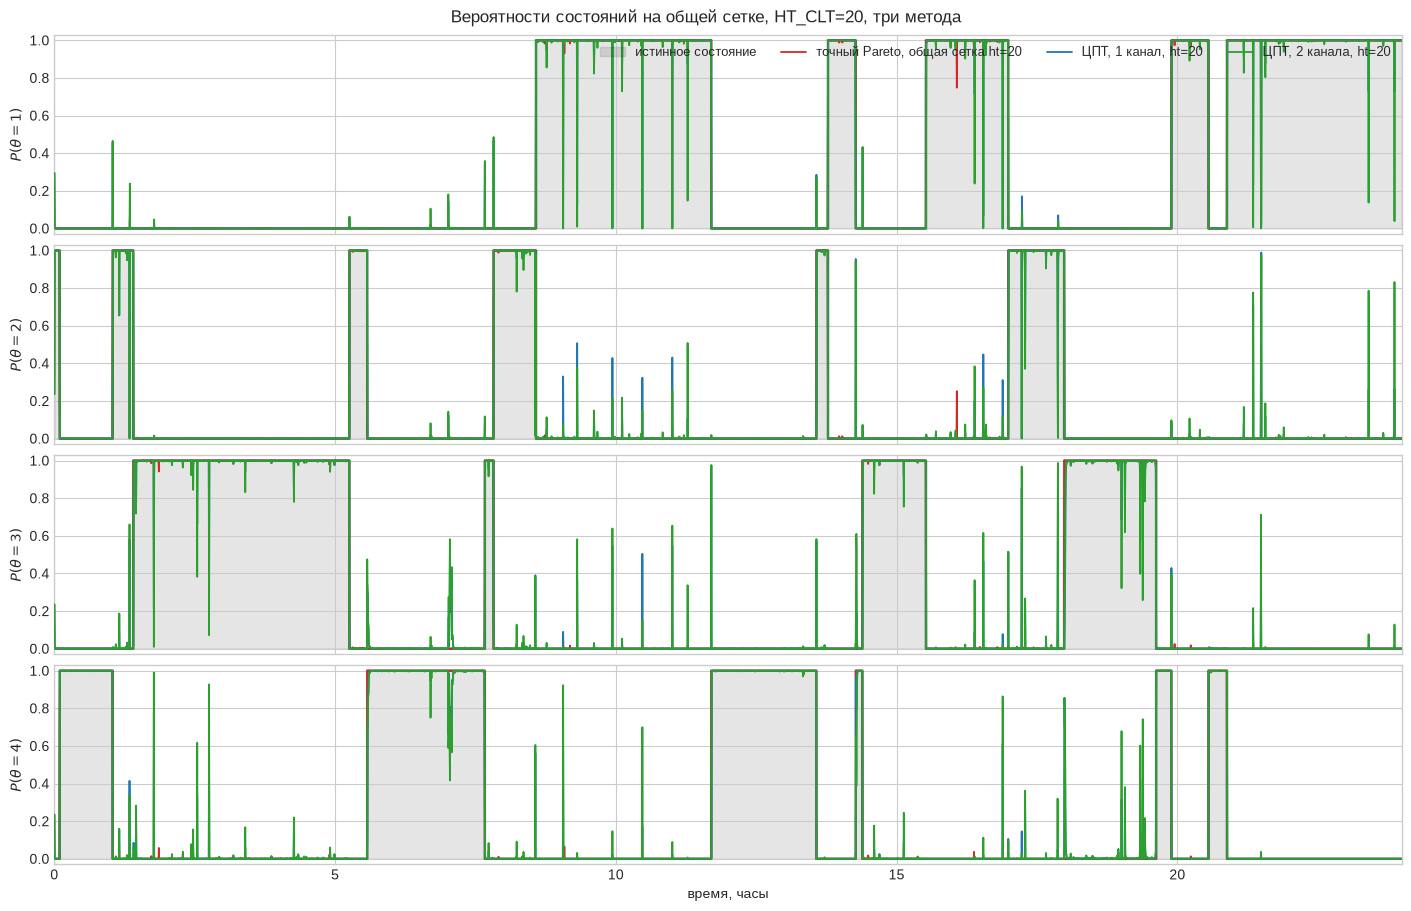

In [6]:
plt.style.use('seaborn-v0_8-whitegrid')
time_hours = t_common / 3600

fig, axes = plt.subplots(
    cfg_exact.N, 1, figsize=(14, 9), sharex=True, layout='constrained'
)
for state, ax in enumerate(axes):
    ax.fill_between(
        time_hours, 0, theta_true_onehot[:, state], step='post',
        color='black', alpha=0.10, zorder=0, label='истинное состояние',
    )
    ax.step(
        time_hours, theta_true_onehot[:, state], where='post',
        color='black', lw=1.8, alpha=0.55, zorder=1,
    )
    ax.plot(
        time_hours, theta_est_exact_common[:, state], color='tab:red',
        lw=1.3, zorder=2, label=f'точный Pareto, общая сетка ht={HT_CLT}',
    )
    ax.plot(
        time_hours, theta_est_one[:, state], color='tab:blue',
        lw=1.3, zorder=3, label=f'ЦПТ, 1 канал, ht={HT_CLT}',
    )
    ax.plot(
        time_hours, theta_est_two[:, state], color='tab:green',
        lw=1.3, zorder=4, label=f'ЦПТ, 2 канала, ht={HT_CLT}',
    )
    ax.set(ylabel=rf'$P(\theta={state + 1})$', ylim=(-0.03, 1.03))
axes[0].legend(loc='upper right', ncol=4, fontsize=9)
axes[-1].set(xlabel='время, часы', xlim=(time_hours[0], time_hours[-1]))
fig.suptitle(f'Вероятности состояний на общей сетке, HT_CLT={HT_CLT}, три метода')
plt.show()

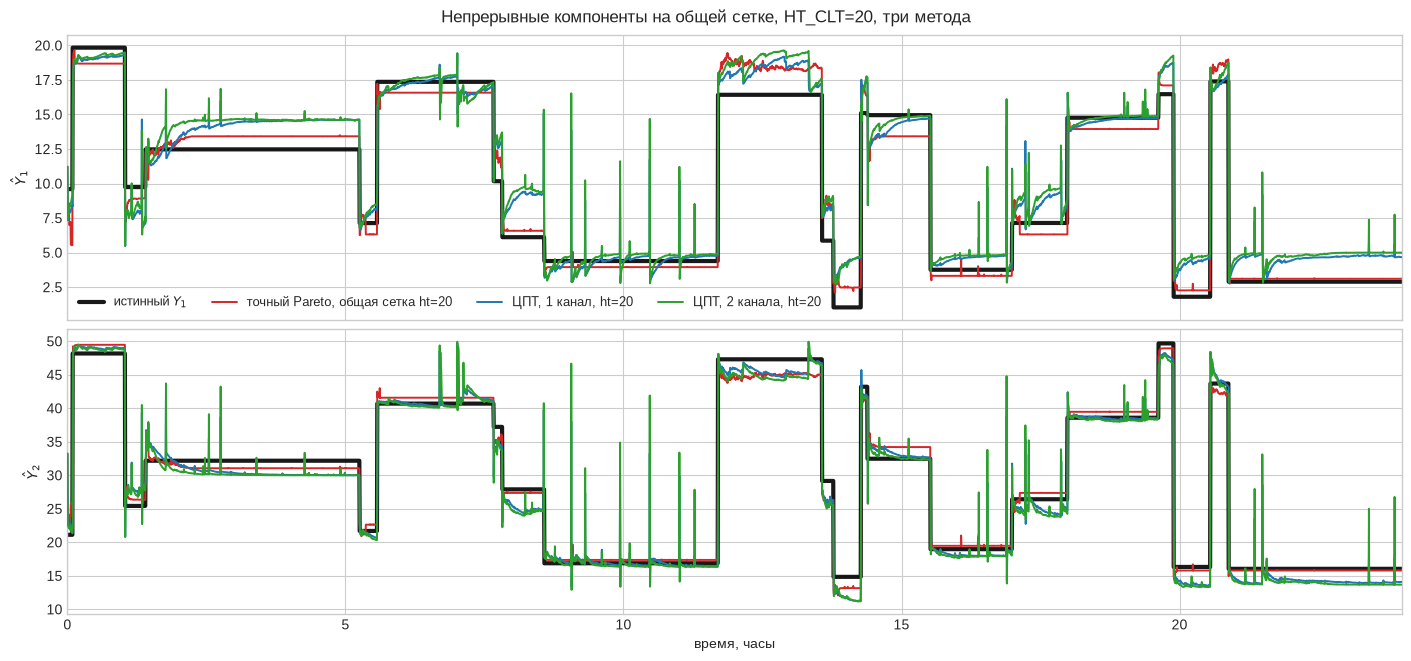

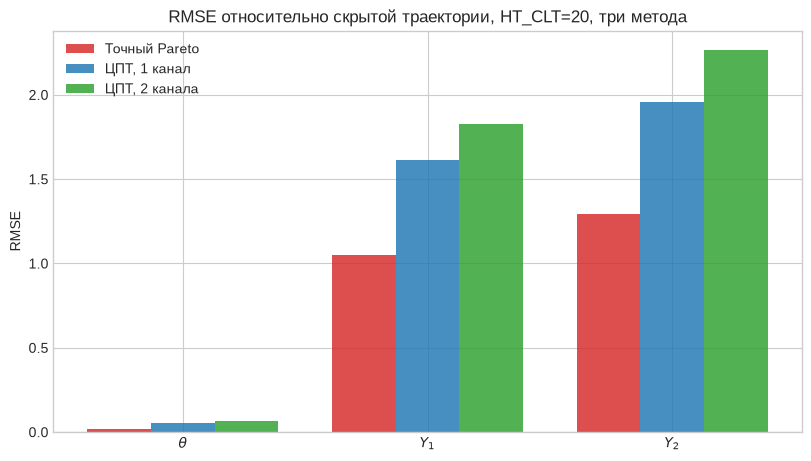

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True, layout='constrained')
for component, ax in enumerate(axes):
    ax.plot(
        time_hours, y_true[:, component], color='black', lw=3.0, alpha=0.9,
        zorder=1, label=fr'истинный $Y_{component + 1}$',
    )
    ax.plot(
        time_hours, y_est_exact_common[:, component], color='tab:red',
        lw=1.4, zorder=2, label=f'точный Pareto, общая сетка ht={HT_CLT}',
    )
    ax.plot(
        time_hours, y_est_one[:, component], color='tab:blue',
        lw=1.4, zorder=3, label=f'ЦПТ, 1 канал, ht={HT_CLT}',
    )
    ax.plot(
        time_hours, y_est_two[:, component], color='tab:green',
        lw=1.4, zorder=4, label=f'ЦПТ, 2 канала, ht={HT_CLT}',
    )
    ax.set_ylabel(fr'$\hat Y_{component + 1}$')
axes[0].legend(loc='best', ncol=4, fontsize=9)
axes[-1].set(xlabel='время, часы', xlim=(time_hours[0], time_hours[-1]))
fig.suptitle(f'Непрерывные компоненты на общей сетке, HT_CLT={HT_CLT}, три метода')
plt.show()

labels = [r'$\theta$', r'$Y_1$', r'$Y_2$']
x = np.arange(len(labels))
width = 0.26
colors = {
    'Точный Pareto': 'tab:red',
    'ЦПТ, 1 канал': 'tab:blue',
    'ЦПТ, 2 канала': 'tab:green',
}
fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')
for offset, (label, values) in zip((-1.0, 0.0, 1.0), metrics.items()):
    ax.bar(x + offset * width, values, width, label=label, color=colors[label], alpha=0.82)
ax.set(
    xticks=x, xticklabels=labels, ylabel='RMSE',
    title=f'RMSE относительно скрытой траектории, HT_CLT={HT_CLT}, три метода',
)
ax.legend()
plt.show()